# 🌿 Nature Medicine vs Pharmaceutical Drugs

This project investigates the growing interest in natural medicine as an alternative to pharmaceutical drugs, especially antibiotics. With concerns about the overuse and side effects of pharmaceuticals, many people are turning to natural remedies for treatment.

The survey aims to understand:
- How many people prefer natural medicine over conventional drugs.
- Perceptions of long-term antibiotic use.
- Which method is seen as more effective and safer.
- How treatment choices vary by age and living environment (urban vs rural).

Data is collected through an online survey using Google Forms and analyzed using Python and statistical tools. The study includes participants from different age groups to identify generational trends and health beliefs.

By visualizing and comparing responses, we aim to highlight patterns in public opinion and the potential role of natural remedies in modern healthcare. This analysis could contribute to a more balanced approach to treatment, blending traditional wisdom with modern medicine.


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
survey = pd.read_csv('survey.csv')

In [3]:
survey.head()

,طابع زمني,كم عمرك؟,ما هو جنسك؟,هل تعيش في منطقة ريفية أم حضرية؟,ما هو مستواك التعليمي؟,هل تعاني من امراض مزمنة (مثل السكر، ضغط الدم، الربو، إلخ),"في حاله اختيارك نعم, ما هو المرض المزمن الذي تعاني منه",متي مرضت اخر مرة؟,ما هو نوع المرض الذي أصبت به مؤخرًا؟,ما العلاج الذي استخدمته ؟,...,هل ترى أن الأدوية الكيميائية تُستخدم أكثر من اللازم في العلاج؟,هل تثق في الوصفات الطبيعية التي يتم تناقلها عبر الأجيال؟,أيهما تعتقد أنه أقل تكلفة؟,هل تجد صعوبة في الحصول على العلاجات الطبيعية؟,هل تجد صعوبة في شراء الأدوية الكيميائية بسبب تكلفتها؟,هل تعتقد أن الأطباء يجب أن يوصوا باستخدام العلاجات الطبيعية بجانب الأدوية الكيميائية؟,من اين تحصل علي الاستشارة الطبية؟,إذا كان لديك خيار بين علاج طبيعي وعلاج دوائي لنفس الحالة، أيهما ستختار؟ ولماذا؟ (إجابة مفتوحة),هل لديك تجارب اضافية حول الادوية الطبيعية و الادوية الصيدلانية,Unnamed: 27
0,2025/03/09 4:40:46 م غرينتش+3,من 18 ل 27 سنة,ذكر,حضرية,تعليم جامعي أو أعلى,لا,NaN,من 1 الي 6 شهور,نزلة برد أو إنفلونزا,دواء صيدلاني(مضاد حيوي او مسكن او دواء حساسية),...,نعم، يجب تقليل استخدامها,أحيانًا، حسب نوع العلاج,العلاج الطبيعي,لا، متوفرة بسهولة,لا، أسعارها مناسبة,نعم، لزيادة الفعالية وتقليل الأضرار,الاطباء;العائلة و الاصدقاء,العلاج الدوائى، اسهل وأسرع فى الاستجابه.,NaN,عبدالرحمن علاء عبدالمجيد
1,2025/03/09 4:42:29 م غرينتش+3,من 18 ل 27 سنة,ذكر,حضرية,تعليم جامعي أو أعلى,لا,NaN,اكثر من 6 شهور,نزلة برد أو إنفلونزا,دواء صيدلاني(مضاد حيوي او مسكن او دواء حساسية),...,لا أعلم,أحيانًا، حسب نوع العلاج,العلاج الطبيعي,لا، متوفرة بسهولة,نعم، أسعارها مرتفعة,لا أعلم,الاطباء;العائلة و الاصدقاء;وسائل التواصل الاجت...,NaN,NaN,اندرو زكريا
2,2025/03/09 4:43:45 م غرينتش+3,من 18 ل 27 سنة,ذكر,حضرية,تعليم جامعي أو أعلى,لا,NaN,خلال اقل من شهر,نزلة برد أو إنفلونزا;مشاكل في المعدة (عسر هضم،...,دواء صيدلاني(مضاد حيوي او مسكن او دواء حساسية),...,لا، استخدامها ضروري,لا، أعتقد أنها غير مثبتة علميًا,العلاج الطبيعي,لا، متوفرة بسهولة,نعم، أسعارها مرتفعة,نعم، لزيادة الفعالية وتقليل الأضرار,الاطباء;وسائل التواصل الاجتماعي (يوتيوب، إنستغ...,علاج دوائى,NaN,بيشوى ابراهيم عيسى
3,2025/03/09 4:44:47 م غرينتش+3,من 18 ل 27 سنة,ذكر,حضرية,تعليم جامعي أو أعلى,لا,NaN,خلال اقل من شهر,حالات جلدية (حساسية، التهابات، إلخ),دواء صيدلاني(مضاد حيوي او مسكن او دواء حساسية),...,نعم، يجب تقليل استخدامها,نعم، أؤمن بفعاليتها,العلاج الطبيعي,نعم، من الصعب العثور عليها,نعم، أسعارها مرتفعة,نعم، لزيادة الفعالية وتقليل الأضرار,الاطباء;العائلة و الاصدقاء;وسائل التواصل الاجت...,علاج طبيعي,لا,احمد ابراهيم
4,2025/03/09 4:47:08 م غرينتش+3,من 18 ل 27 سنة,ذكر,حضرية,تعليم جامعي أو أعلى,نعم,حساسية الأنف المزمنة,من 1 الي 6 شهور,أعراض أخرى مرتبطة بالأمراض المزمنة,دواء صيدلاني(مضاد حيوي او مسكن او دواء حساسية),...,لا أعلم,نعم، أؤمن بفعاليتها,العلاج الطبيعي,نعم، من الصعب العثور عليها,نعم، أسعارها مرتفعة,نعم، لزيادة الفعالية وتقليل الأضرار,الاطباء,NaN,NaN,عمر عبدالستار


## Translating the data for begining

In [4]:
import pandas as pd
import numpy as np

def translate_multiple_choices(text):
    if pd.isna(text) or text == "":
        return ""
    
    # Convert to string in case it's not
    text = str(text).strip()
    
    # Handle cases where multiple choices are separated by semicolons or commas
    if ';' in text:
        split_char = ';'
    elif ',' in text:
        split_char = ','
    else:
        split_char = None
    
    translations = {
        "السكر": "Diabetes",
        "ضغط الدم": "High blood pressure",
        "الربو": "Asthma",
        "أمراض الجهاز التنفسي المزمنة": "Chronic respiratory diseases",
        "حساسية الأنف المزمنة": "Chronic nasal allergy",
        "الغده الدرقية": "Thyroid",
        "بعاني من جرثومة في المعدة مزمنة مع حموضة دائمة وشديدة": "Suffer from chronic stomach bacteria with severe acidity",
        "لم أعاني": "Did not suffer",
        "الاذان الوسطى": "Middle ear",
        "لا شئ": "Nothing",
        "أمراض كلي": "Kidney diseases",
        "التهاب الروماتويد المفصلي": "Rheumatoid arthritis",
        "لا": "No",
        "نزلة برد أو إنفلونزا": "Cold or flu",
        "مشاكل في المعدة (عسر هضم، تسمم غذائي، إلخ)": "Stomach problems (indigestion, food poisoning, etc.)",
        "حالات جلدية (حساسية، التهابات، إلخ)": "Skin conditions (allergies, infections, etc.)",
        "إرتفاع او إنخفاض ضغط الدم": "High or low blood pressure",
        "أمراض الجهاز التنفسي (حساسية الأنف، التهاب الشعب الهوائية)": "Respiratory diseases (nasal allergy, bronchitis)",
        "أعراض أخرى مرتبطة بالأمراض المزمنة": "Other symptoms related to chronic diseases",
        "التهاب في الجيوب الانفية": "Sinusitis",
        "دوار": "Dizziness",
        "كسر في الساق": "Leg fracture",
        "برد": "Cold",
        "دهون ثلاثية وكولستيرول": "Triglycerides and cholesterol",
        "عظام": "Bones",
        "الاطباء": "Doctors",
        "العائلة و الاصدقاء": "Family and friends",
        "وسائل التواصل الاجتماعي (يوتيوب، إنستغرام، إلخ)": "Social media (YouTube, Instagram, etc.)",
        "البحث عبر الإنترنت (جوجل، المدونات، المقالات)": "Online search (Google, blogs, articles)",
        "المعالجون التقليديون أو العطارون": "Traditional healers or herbalists",
        "انا": "Myself",
        "نادرًا الإنترنت إن كانت الحالة خفيفة": "Rarely the internet if the condition is mild",
        "chat gpt": "Chat GPT",
        "فعال اكثر": "More effective",
        "اعراض جانبية اقل": "Fewer side effects",
        "سعره مناسب": "Affordable price",
        "سهل الحصول عليه": "Easy to obtain",
        "Other…": "Other",
        "Other": "Other",
        "nan": "",  # Handle NaN strings
        "None": "",
        "Null": "",
        "": ""
    }
    
    if split_char:
        split_choices = text.split(split_char)
        # Clean each choice by stripping whitespace and removing any trailing semicolons
        cleaned_choices = [choice.strip().rstrip(';').strip() for choice in split_choices]
        translated_choices = []
        for choice in cleaned_choices:
            translated = translations.get(choice, "")
            if translated:  # Only keep non-empty translations
                translated_choices.append(translated)
        return '; '.join(translated_choices) if translated_choices else ""
    else:
        return translations.get(text, "")

def process_survey_data(df):
    # Make a copy of the dataframe to avoid SettingWithCopyWarning
    df = df.copy()
    
    # Trim column names and strip any whitespace
    df.columns = df.columns.str.strip()
    
    # Replace any NA values with empty strings first
    df = df.fillna("")
    
    # Rename columns
    df = df.rename(columns={
        "كم عمرك؟": "Age",
        "ما هو جنسك؟": "Gender",
        "هل تعيش في منطقة ريفية أم حضرية؟": "Living_Area",
        "ما هو مستواك التعليمي؟": "Education_Level",
        "هل تعاني من امراض مزمنة  (مثل السكر، ضغط الدم، الربو، إلخ)": "Chronic_Illness",
        "في حاله اختيارك نعم, ما هو المرض المزمن الذي تعاني منه": "Chronic_Disease_Type",
        "متي مرضت اخر مرة؟": "Last_Illness_Time",
        "ما هو نوع المرض الذي أصبت به مؤخرًا؟": "Recent_Illness_Type",
        "ما العلاج الذي استخدمته ؟": "Recent_Treatment",
        "ماذا تفضل اكثر  ؟": "Preference",
        "لماذا تفضل اختيارك؟": "Preference_Reason",
        "كيف تستخدم الادوية الطبيعية": "Natural_Medicine_Usage",
        "كيف تستخدم الادوية الصيدلانية": "Pharmaceutical_Usage",
        "هل تعتقد أن الطب الطبيعي فعال مثل الأدوية الصيدلانية؟": "Natural_vs_Pharmaceutical",
        "هل تعتقد أن الاستخدام طويل الأمد للأدوية الصيدلانية (مثل المضادات الحيوية، مسكنات الألم) ضار؟": "Long_Term_Pharmaceutical_Concern",
        "هل لديك معرفة بأي تفاعلات محتملة بين الأدوية الطبيعية والأدوية الصيدلانية؟": "Drug_Interaction_Knowledge",
        "هل جربت علاجًا طبيعيًا وكان أكثر فاعلية بالنسبة لك من الأدوية الصيدلانية؟": "Effective_Natural_Treatment",
        "هل ترى أن الأدوية الكيميائية تُستخدم أكثر من اللازم في العلاج؟": "Overuse_of_Chemical_Medicine",
        "هل تثق في الوصفات الطبيعية التي يتم تناقلها عبر الأجيال؟": "Trust_Traditional_Recipes",
        "أيهما تعتقد أنه أقل تكلفة؟": "Cost_Comparison",
        "هل تجد صعوبة في الحصول على العلاجات الطبيعية؟": "Difficulty_Accessing_Natural_Treatments",
        "هل تجد صعوبة في شراء الأدوية الكيميائية بسبب تكلفتها؟": "Difficulty_Affording_Chemical_Medicine",
        "هل تعتقد أن الأطباء يجب أن يوصوا باستخدام العلاجات الطبيعية بجانب الأدوية الكيميائية؟": "Doctors_Should_Recommend_Natural",
        "من اين تحصل علي الاستشارة الطبية؟": "Source_of_Medical_Advice"
    })
    
    # Translate column values - replace unknown values with blank
    df['Age'] = df['Age'].replace({
        "أقل من 18 سنة": "Under 18 years",
        "من 18 ل 27 سنة": "18 to 27 years",
        "من 28 ل 40 سنة": "28 to 40 years",
        "أكثر من 40 سنة": "Over 40 years"
    }).replace(r'^(?!Under 18 years|18 to 27 years|28 to 40 years|Over 40 years).*$', "", regex=True)
    
    df['Gender'] = df['Gender'].replace({
        "ذكر": "Male",
        "أنثى": "Female"
    }).replace(r'^(?!Male|Female).*$', "", regex=True)
    
    df['Living_Area'] = df['Living_Area'].replace({
        "ريفية": "Rural",
        "حضرية": "Urban"
    }).replace(r'^(?!Rural|Urban).*$', "", regex=True)
    
    df['Education_Level'] = df['Education_Level'].replace({
        "لم أكمل الدراسة": "Did not complete education",
        "تعليم ابتدائي أو اعدادى": "Primary or preparatory education",
        "تعليم ثانوى": "Secondary education",
        "تعليم جامعي أو أعلى": "University education or higher"
    }).replace(r'^(?!Did not complete education|Primary or preparatory education|Secondary education|University education or higher).*$', "", regex=True)
    
    df['Chronic_Illness'] = df['Chronic_Illness'].replace({
        "نعم": "Yes",
        "لا": "No"
    }).replace(r'^(?!Yes|No).*$', "", regex=True)
    
    df['Chronic_Disease_Type'] = df['Chronic_Disease_Type'].apply(translate_multiple_choices)
    df['Chronic_Disease_Type'] = df['Chronic_Disease_Type'].replace("_", "")
    
    df['Last_Illness_Time'] = df['Last_Illness_Time'].replace({
        "خلال اقل من شهر": "Within less than a month",
        "من 1 الي 6 شهور": "1 to 6 months ago",
        "اكثر من 6 شهور": "More than 6 months ago",
        "لا أتذكر": "I don't remember"
    }).replace(r'^(?!Within less than a month|1 to 6 months ago|More than 6 months ago|I don\'t remember).*$', "", regex=True)
    
    df['Recent_Illness_Type'] = df['Recent_Illness_Type'].apply(translate_multiple_choices)
    
    df['Recent_Treatment'] = df['Recent_Treatment'].replace({
        "دواء طبيعي (اعشاب او وصفة منزلية)": "Natural medicine (herbs or home remedy)",
        "دواء صيدلاني(مضاد حيوي او مسكن او دواء حساسية)": "Pharmaceutical medicine (antibiotic, painkiller, or allergy medicine)",
        "مزيج منهم": "A combination of both",
        "لم تسخدم دواء": "Did not use any medicine"
    }).replace(r'^(?!Natural medicine \(herbs or home remedy\)|Pharmaceutical medicine \(antibiotic, painkiller, or allergy medicine\)|A combination of both|Did not use any medicine).*$', "", regex=True)
    
    df['Preference'] = df['Preference'].replace({
        "دواء طبيعي": "Natural medicine",
        "دواء صيدلاني": "Pharmaceutical medicine",
        "لا افضل شئ": "I don't prefer anything"
    }).replace(r'^(?!Natural medicine|Pharmaceutical medicine|I don\'t prefer anything).*$', "", regex=True)
    
    df['Preference_Reason'] = df['Preference_Reason'].apply(translate_multiple_choices)
    
    df['Natural_Medicine_Usage'] = df['Natural_Medicine_Usage'].replace({
        "بانتظام (يوميا او اسبوعيا ..)": "Regularly (daily or weekly)",
        "مرات متفرقة": "Occasionally",
        "نادرا": "Rarely",
        "ابدا": "Never"
    }).replace(r'^(?!Regularly \(daily or weekly\)|Occasionally|Rarely|Never).*$', "", regex=True)
    
    df['Pharmaceutical_Usage'] = df['Pharmaceutical_Usage'].replace({
        "بانتظام (يوميا او اسبوعيا ..)": "Regularly (daily or weekly)",
        "مرات متفرقة": "Occasionally",
        "نادرا": "Rarely",
        "ابدا": "Never"
    }).replace(r'^(?!Regularly \(daily or weekly\)|Occasionally|Rarely|Never).*$', "", regex=True)
    
    df['Natural_vs_Pharmaceutical'] = df['Natural_vs_Pharmaceutical'].replace({
        "نعم": "Yes",
        "لا": "No",
        "ربما": "Maybe"
    }).replace(r'^(?!Yes|No|Maybe).*$', "", regex=True)
    
    df['Long_Term_Pharmaceutical_Concern'] = df['Long_Term_Pharmaceutical_Concern'].replace({
        "نعم لها اثار جانبية": "Yes, it has side effects",
        "لا اذا استخدمت بشكل صحيح": "No, if used correctly",
        "ربما": "Maybe",
        "في النهايه كل الادوية سموم بالتالي لها تأثير": "In the end, all medicines are toxins and thus have an effect"
    }).replace(r'^(?!Yes, it has side effects|No, if used correctly|Maybe|In the end, all medicines are toxins and thus have an effect).*$', "", regex=True)
    
    df['Drug_Interaction_Knowledge'] = df['Drug_Interaction_Knowledge'].replace({
        "نعم": "Yes",
        "لا": "No",
        "ربما": "Maybe"
    }).replace(r'^(?!Yes|No|Maybe).*$', "", regex=True)
    
    df['Effective_Natural_Treatment'] = df['Effective_Natural_Treatment'].replace({
        "نعم": "Yes",
        "لا": "No"
    }).replace(r'^(?!Yes|No).*$', "", regex=True)
    
    df['Overuse_of_Chemical_Medicine'] = df['Overuse_of_Chemical_Medicine'].replace({
        "نعم، يجب تقليل استخدامها": "Yes, their use should be reduced",
        "لا، استخدامها ضروري": "No, their use is necessary",
        "لا أعلم": "I don't know",
        "ربما": "Maybe"
    }).replace(r'^(?!Yes, their use should be reduced|No, their use is necessary|I don\'t know|Maybe).*$', "", regex=True)
    
    df['Trust_Traditional_Recipes'] = df['Trust_Traditional_Recipes'].replace({
        "نعم، أؤمن بفعاليتها": "Yes, I believe in their effectiveness",
        "لا، أعتقد أنها غير مثبتة علميًا": "No, I think they are not scientifically proven",
        "أحيانًا، حسب نوع العلاج": "Sometimes, depending on the type of treatment"
    }).replace(r'^(?!Yes, I believe in their effectiveness|No, I think they are not scientifically proven|Sometimes, depending on the type of treatment).*$', "", regex=True)
    
    df['Cost_Comparison'] = df['Cost_Comparison'].replace({
        "العلاج الطبيعي": "Natural treatment",
        "الأدوية الكيميائية": "Chemical medicines",
        "لا يوجد فرق كبير": "No significant difference"
    }).replace(r'^(?!Natural treatment|Chemical medicines|No significant difference).*$', "", regex=True)
    
    df['Difficulty_Accessing_Natural_Treatments'] = df['Difficulty_Accessing_Natural_Treatments'].replace({
        "نعم، من الصعب العثور عليها": "Yes, it's hard to find them",
        "لا، متوفرة بسهولة": "No, they are easily available"
    }).replace(r'^(?!Yes, it\'s hard to find them|No, they are easily available).*$', "", regex=True)
    
    df['Difficulty_Affording_Chemical_Medicine'] = df['Difficulty_Affording_Chemical_Medicine'].replace({
        "نعم، أسعارها مرتفعة": "Yes, their prices are high",
        "لا، أسعارها مناسبة": "No, their prices are reasonable"
    }).replace(r'^(?!Yes, their prices are high|No, their prices are reasonable).*$', "", regex=True)
    
    df['Doctors_Should_Recommend_Natural'] = df['Doctors_Should_Recommend_Natural'].replace({
        "نعم، لزيادة الفعالية وتقليل الأضرار": "Yes, to increase effectiveness and reduce harm",
        "لا، الأدوية الكيميائية كافية": "No, chemical medicines are sufficient",
        "لا أعلم": "I don't know"
    }).replace(r'^(?!Yes, to increase effectiveness and reduce harm|No, chemical medicines are sufficient|I don\'t know).*$', "", regex=True)
    
    # Special handling for Source_of_Medical_Advice which uses semicolons as separators
    df['Source_of_Medical_Advice'] = df['Source_of_Medical_Advice'].apply(translate_multiple_choices)
    
    column_order = [
        'Age', 'Gender', 'Living_Area', 'Education_Level', 'Chronic_Illness', 
        'Chronic_Disease_Type', 'Last_Illness_Time', 'Recent_Illness_Type', 
        'Recent_Treatment', 'Preference', 'Preference_Reason', 'Natural_Medicine_Usage', 
        'Pharmaceutical_Usage', 'Natural_vs_Pharmaceutical', 'Long_Term_Pharmaceutical_Concern', 
        'Drug_Interaction_Knowledge', 'Effective_Natural_Treatment', 'Overuse_of_Chemical_Medicine', 
        'Trust_Traditional_Recipes', 'Cost_Comparison', 'Difficulty_Accessing_Natural_Treatments', 
        'Difficulty_Affording_Chemical_Medicine', 'Doctors_Should_Recommend_Natural', 
        'Source_of_Medical_Advice'
    ]
    
    # Ensure all remaining NA values are replaced with empty strings
    df = df.fillna("")
    
    # Convert all columns to string and strip whitespace
    df = df.applymap(lambda x: str(x).strip() if pd.notna(x) else "")
    
    return df[column_order]

eng_survey = process_survey_data(survey)
eng_survey = eng_survey.replace('', np.nan)

In [5]:
eng_survey.head()

,Age,Gender,Living_Area,Education_Level,Chronic_Illness,Chronic_Disease_Type,Last_Illness_Time,Recent_Illness_Type,Recent_Treatment,Preference,...,Long_Term_Pharmaceutical_Concern,Drug_Interaction_Knowledge,Effective_Natural_Treatment,Overuse_of_Chemical_Medicine,Trust_Traditional_Recipes,Cost_Comparison,Difficulty_Accessing_Natural_Treatments,Difficulty_Affording_Chemical_Medicine,Doctors_Should_Recommend_Natural,Source_of_Medical_Advice
0,18 to 27 years,Male,Urban,University education or higher,No,NaN,1 to 6 months ago,Cold or flu,"Pharmaceutical medicine (antibiotic, painkille...",Pharmaceutical medicine,...,"Yes, it has side effects",No,No,"Yes, their use should be reduced","Sometimes, depending on the type of treatment",Natural treatment,"No, they are easily available","No, their prices are reasonable","Yes, to increase effectiveness and reduce harm",Doctors; Family and friends
1,18 to 27 years,Male,Urban,University education or higher,No,NaN,More than 6 months ago,Cold or flu,"Pharmaceutical medicine (antibiotic, painkille...",Pharmaceutical medicine,...,"Yes, it has side effects",No,No,I don't know,"Sometimes, depending on the type of treatment",Natural treatment,"No, they are easily available","Yes, their prices are high",I don't know,Doctors; Family and friends; Social media (You...
2,18 to 27 years,Male,Urban,University education or higher,No,NaN,Within less than a month,"Cold or flu; Stomach problems (indigestion, fo...","Pharmaceutical medicine (antibiotic, painkille...",Pharmaceutical medicine,...,"Yes, it has side effects",No,Yes,"No, their use is necessary","No, I think they are not scientifically proven",Natural treatment,"No, they are easily available","Yes, their prices are high","Yes, to increase effectiveness and reduce harm","Doctors; Social media (YouTube, Instagram, etc.)"
3,18 to 27 years,Male,Urban,University education or higher,No,NaN,Within less than a month,"Skin conditions (allergies, infections, etc.)","Pharmaceutical medicine (antibiotic, painkille...",Natural medicine,...,"No, if used correctly",No,Yes,"Yes, their use should be reduced","Yes, I believe in their effectiveness",Natural treatment,"Yes, it's hard to find them","Yes, their prices are high","Yes, to increase effectiveness and reduce harm",Doctors; Family and friends; Social media (You...
4,18 to 27 years,Male,Urban,University education or higher,Yes,Chronic nasal allergy,1 to 6 months ago,Other symptoms related to chronic diseases,"Pharmaceutical medicine (antibiotic, painkille...",Natural medicine,...,"Yes, it has side effects",No,No,I don't know,"Yes, I believe in their effectiveness",Natural treatment,"Yes, it's hard to find them","Yes, their prices are high","Yes, to increase effectiveness and reduce harm",Doctors


## EDA

In [6]:
df = eng_survey.copy()

In [7]:
df.shape

(257, 24)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Age                                      255 non-null    object
 1   Gender                                   255 non-null    object
 2   Living_Area                              255 non-null    object
 3   Education_Level                          255 non-null    object
 4   Chronic_Illness                          255 non-null    object
 5   Chronic_Disease_Type                     68 non-null     object
 6   Last_Illness_Time                        255 non-null    object
 7   Recent_Illness_Type                      252 non-null    object
 8   Recent_Treatment                         255 non-null    object
 9   Preference                               255 non-null    object
 10  Preference_Reason                        249 non-null    objec

In [9]:
df.nunique()

Age                                         4
Gender                                      2
Living_Area                                 2
Education_Level                             4
Chronic_Illness                             2
Chronic_Disease_Type                       23
Last_Illness_Time                           4
Recent_Illness_Type                        34
Recent_Treatment                            4
Preference                                  3
Preference_Reason                          14
Natural_Medicine_Usage                      4
Pharmaceutical_Usage                        4
Natural_vs_Pharmaceutical                   3
Long_Term_Pharmaceutical_Concern            3
Drug_Interaction_Knowledge                  3
Effective_Natural_Treatment                 2
Overuse_of_Chemical_Medicine                4
Trust_Traditional_Recipes                   3
Cost_Comparison                             3
Difficulty_Accessing_Natural_Treatments     2
Difficulty_Affording_Chemical_Medi

In [10]:
for column in df.columns:
    print(f"Value counts for column '{column}':\n")
    print(df[column].value_counts())
    print("\n" + "-"*40 + "\n")

Value counts for column 'Age':

Age
18 to 27 years    184
Over 40 years      36
28 to 40 years     23
Under 18 years     12
Name: count, dtype: int64

----------------------------------------

Value counts for column 'Gender':

Gender
Male      137
Female    118
Name: count, dtype: int64

----------------------------------------

Value counts for column 'Living_Area':

Living_Area
Urban    212
Rural     43
Name: count, dtype: int64

----------------------------------------

Value counts for column 'Education_Level':

Education_Level
University education or higher      215
Secondary education                  31
Primary or preparatory education      6
Did not complete education            3
Name: count, dtype: int64

----------------------------------------

Value counts for column 'Chronic_Illness':

Chronic_Illness
No     201
Yes     54
Name: count, dtype: int64

----------------------------------------

Value counts for column 'Chronic_Disease_Type':

Chronic_Disease_Type
Chronic nas

## Preprocessing

In [11]:
print("Blank rows before removal:", df.isna().all(axis=1).sum())
df = df.dropna(how='all')
print("Blank rows after removal:", df.isnull().all(axis=1).sum())

Blank rows before removal: 2
Blank rows after removal: 0


In [12]:
df.isna().sum()

Age                                          0
Gender                                       0
Living_Area                                  0
Education_Level                              0
Chronic_Illness                              0
Chronic_Disease_Type                       187
Last_Illness_Time                            0
Recent_Illness_Type                          3
Recent_Treatment                             0
Preference                                   0
Preference_Reason                            6
Natural_Medicine_Usage                       0
Pharmaceutical_Usage                         0
Natural_vs_Pharmaceutical                    0
Long_Term_Pharmaceutical_Concern             1
Drug_Interaction_Knowledge                   0
Effective_Natural_Treatment                  0
Overuse_of_Chemical_Medicine                 0
Trust_Traditional_Recipes                    0
Cost_Comparison                              0
Difficulty_Accessing_Natural_Treatments      0
Difficulty_Af

In [13]:
df['Chronic_Disease_Type'] = df['Chronic_Disease_Type'].fillna('None')

In [14]:
df = df.fillna('Unknown')

In [15]:
df.isna().sum()

Age                                        0
Gender                                     0
Living_Area                                0
Education_Level                            0
Chronic_Illness                            0
Chronic_Disease_Type                       0
Last_Illness_Time                          0
Recent_Illness_Type                        0
Recent_Treatment                           0
Preference                                 0
Preference_Reason                          0
Natural_Medicine_Usage                     0
Pharmaceutical_Usage                       0
Natural_vs_Pharmaceutical                  0
Long_Term_Pharmaceutical_Concern           0
Drug_Interaction_Knowledge                 0
Effective_Natural_Treatment                0
Overuse_of_Chemical_Medicine               0
Trust_Traditional_Recipes                  0
Cost_Comparison                            0
Difficulty_Accessing_Natural_Treatments    0
Difficulty_Affording_Chemical_Medicine     0
Doctors_Sh

In [16]:
df.duplicated().sum()

0

In [17]:
# Save the clean translated data
# df.to_csv('English_Survey.csv', index=False)

In [18]:
for column in df.columns:
    print(f"Value counts for column '{column}':\n")
    print(df[column].value_counts())
    print("\n" + "-"*40 + "\n")

Value counts for column 'Age':

Age
18 to 27 years    184
Over 40 years      36
28 to 40 years     23
Under 18 years     12
Name: count, dtype: int64

----------------------------------------

Value counts for column 'Gender':

Gender
Male      137
Female    118
Name: count, dtype: int64

----------------------------------------

Value counts for column 'Living_Area':

Living_Area
Urban    212
Rural     43
Name: count, dtype: int64

----------------------------------------

Value counts for column 'Education_Level':

Education_Level
University education or higher      215
Secondary education                  31
Primary or preparatory education      6
Did not complete education            3
Name: count, dtype: int64

----------------------------------------

Value counts for column 'Chronic_Illness':

Chronic_Illness
No     201
Yes     54
Name: count, dtype: int64

----------------------------------------

Value counts for column 'Chronic_Disease_Type':

Chronic_Disease_Type
None       

In [19]:
df = df.drop(columns=[
    'Source_of_Medical_Advice',
    'Preference_Reason',
    'Recent_Illness_Type',
    'Chronic_Disease_Type'
])

In [20]:
# Data encoding
le = LabelEncoder()

for column in df.select_dtypes(include=['object']).columns:
    df[column] = le.fit_transform(df[column])

In [21]:
df.head()

,Age,Gender,Living_Area,Education_Level,Chronic_Illness,Last_Illness_Time,Recent_Treatment,Preference,Natural_Medicine_Usage,Pharmaceutical_Usage,Natural_vs_Pharmaceutical,Long_Term_Pharmaceutical_Concern,Drug_Interaction_Knowledge,Effective_Natural_Treatment,Overuse_of_Chemical_Medicine,Trust_Traditional_Recipes,Cost_Comparison,Difficulty_Accessing_Natural_Treatments,Difficulty_Affording_Chemical_Medicine,Doctors_Should_Recommend_Natural
0,0,1,1,3,0,0,3,2,1,1,0,3,1,0,3,1,1,0,0,2
1,0,1,1,3,0,2,3,2,2,3,0,3,1,0,0,1,1,0,1,0
2,0,1,1,3,0,3,3,2,3,1,1,3,1,1,2,0,1,0,1,2
3,0,1,1,3,0,3,3,1,1,1,2,1,1,1,3,2,1,1,1,2
4,0,1,1,3,1,0,3,1,3,3,2,3,1,0,0,2,1,1,1,2


## Correlation Matrix

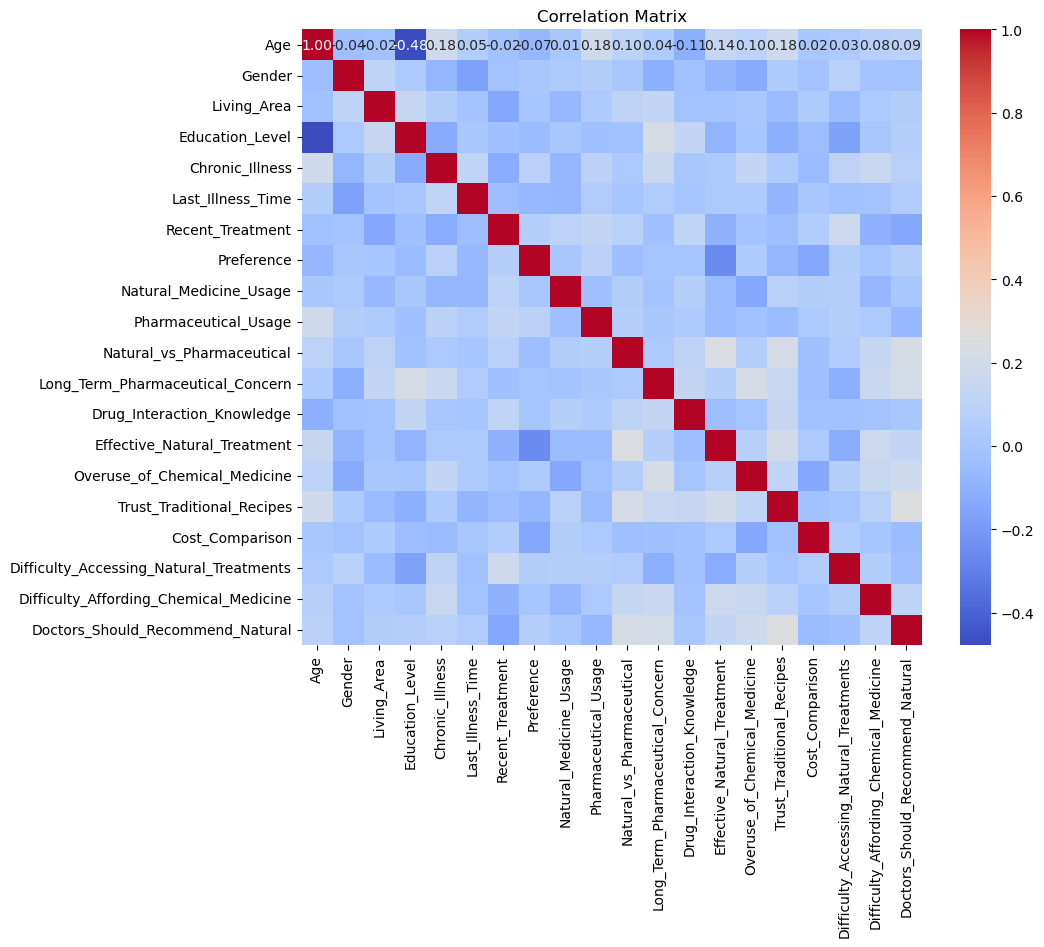

In [22]:
corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## Chi-Square Test P-Value MAtrix

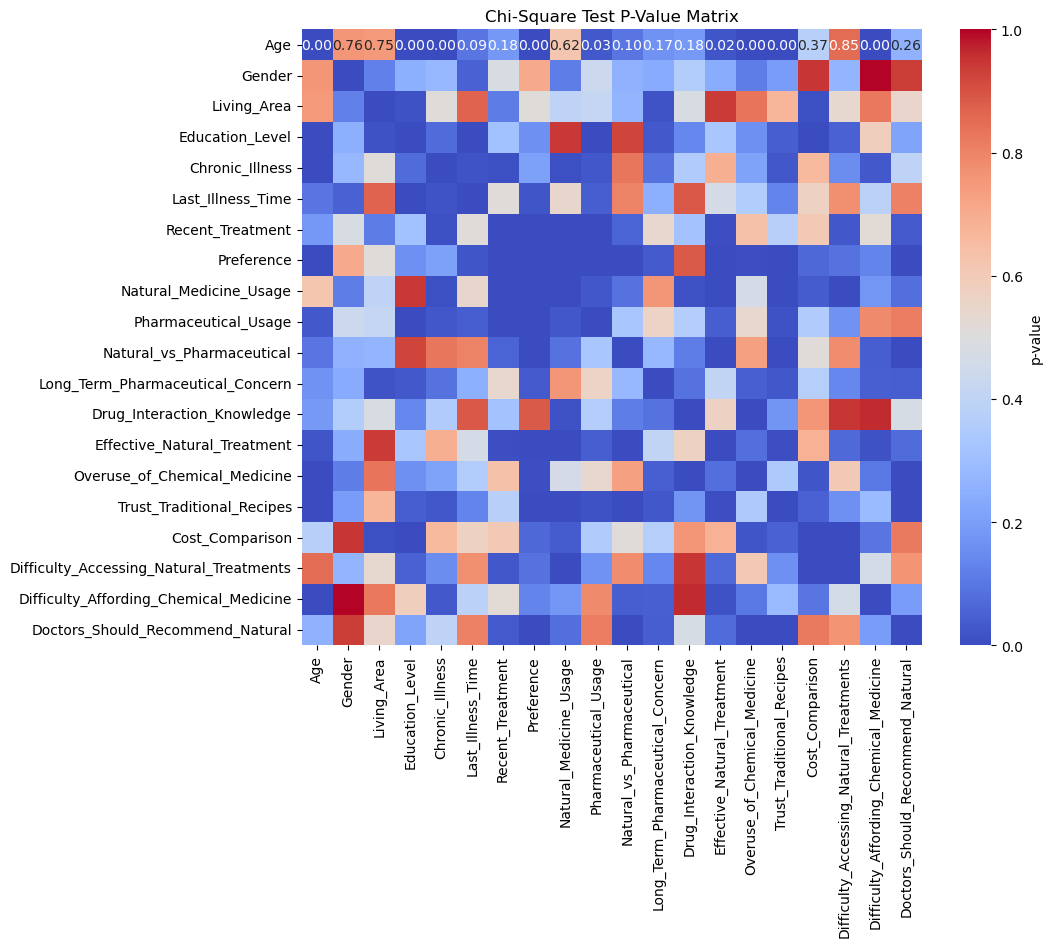

In [23]:
def chi_square_test(df):
    chi_square_matrix = pd.DataFrame(index=df.columns, columns=df.columns)
    for col1 in df.columns:
        for col2 in df.columns:
            contingency_table = pd.crosstab(df[col1], df[col2])
            _, p_value, _, _ = chi2_contingency(contingency_table)
            chi_square_matrix.loc[col1, col2] = p_value
    return chi_square_matrix

chi_square_matrix = chi_square_test(df)
chi_square_matrix = chi_square_matrix.astype(float)

plt.figure(figsize=(10, 8))
sns.heatmap(chi_square_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label': 'p-value'})
plt.title('Chi-Square Test P-Value Matrix')
plt.show()

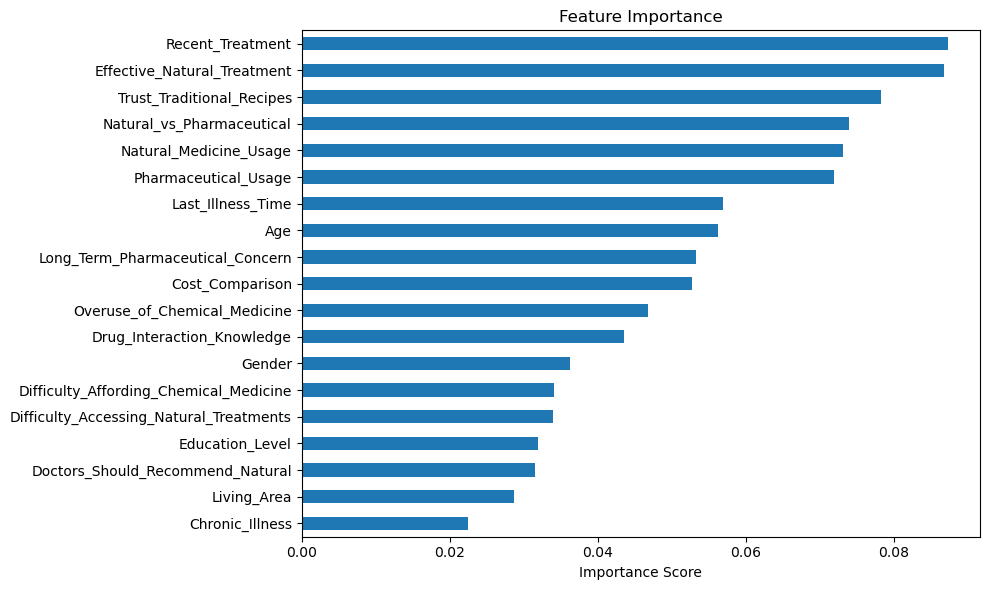

In [24]:
target = 'Preference'

X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
selected_features = feature_importance[feature_importance > 0.02].index
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [26]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), 
                          param_grid, 
                          cv=5, 
                          scoring='accuracy')
grid_search.fit(X_train_selected, y_train)

best_model = grid_search.best_estimator_

Accuracy: 0.6078431372549019
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.54      0.76      0.63        17
           2       0.67      0.67      0.67        27

    accuracy                           0.61        51
   macro avg       0.40      0.48      0.43        51
weighted avg       0.53      0.61      0.56        51



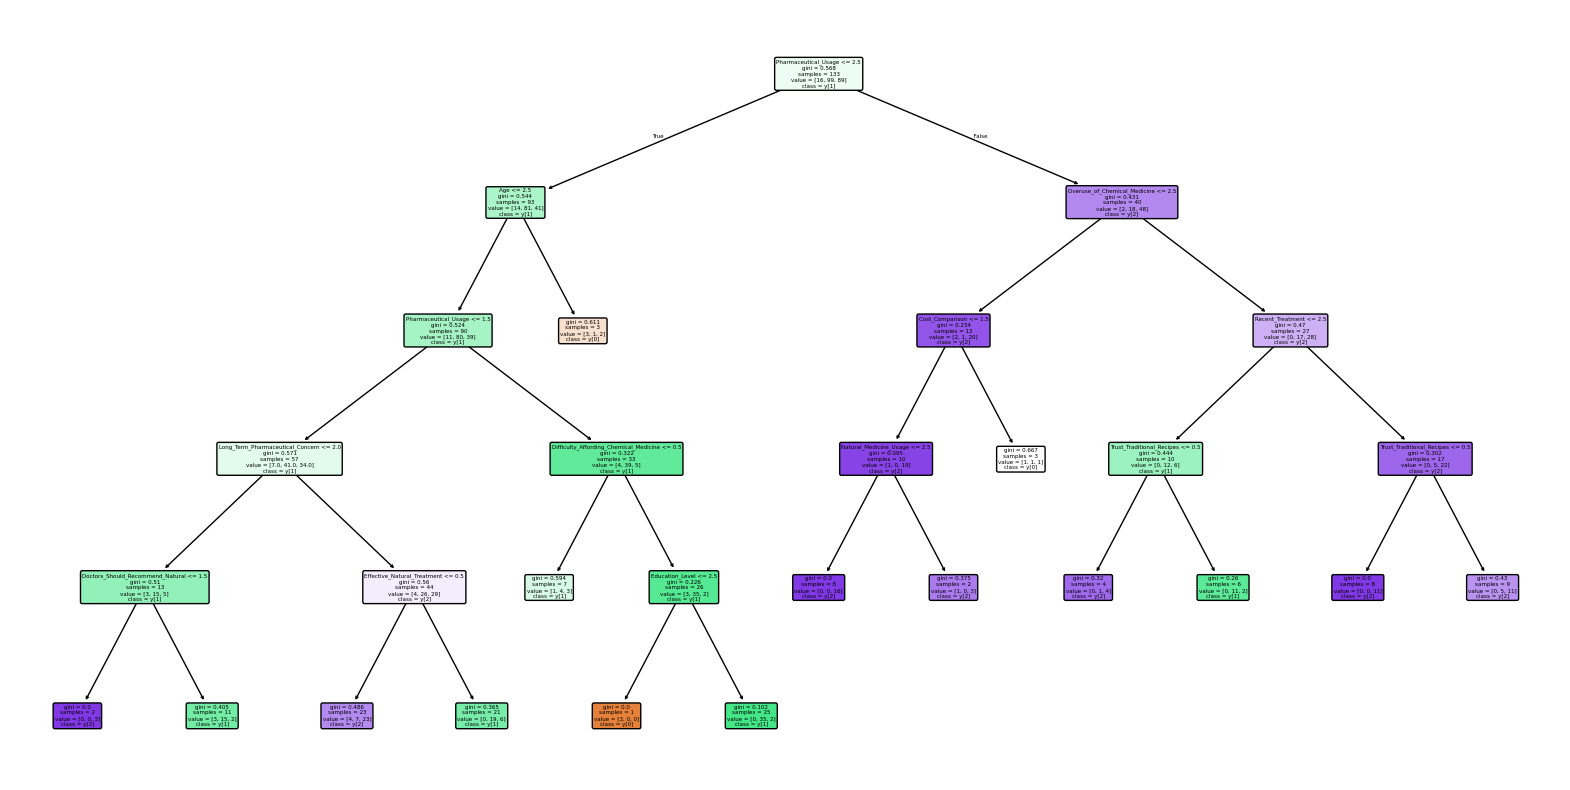

In [27]:
y_pred = best_model.predict(X_test_selected)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(20,10))
plot_tree(best_model.estimators_[0], feature_names=X_train_selected.columns, class_names=True, filled=True, rounded=True)
plt.show()